# Credit Card Fraud Detection

## Imports

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv('creditcard.csv')

## Business Problem

Fraudulent transactions result in direct financial losses and damage customer trust. This project aimed to build a model, which would automatically detect fraudulent transactions.

The goals of this analysis are to:
1. Identify the key factors associated with fraudulent transactions
2. Build a machine learning model that predicts whether a transaction is fraudulent
3. Minimise financial losses by maximising detection of fraud

## Data Dictionary

| Column | Type | Description |
|--------|------|-------------|
| Time | float64 | Seconds elapsed between each transaction and the first transaction in the dataset |
| V1-V28 | float64 | Anonymous features - result of PCA transformation. Original features not shared for confidentiality |
| Amount | float64 | Transaction amount in euros |
| Class | int64 | Target variable - 0: legitimate transaction, 1: fraudulent transaction |

## Data Understanding

In [3]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


The first 10 rows confirm that the data has loaded correctly. The structure matches data dictionary. Numerical features are in expected ranges of values.

In [4]:
df.shape

(284807, 31)

The dataset contains 284807 rows and 31 columns.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

All columns have the same data types as described in data dictionary. No type conversions are needed at this stage.

In [6]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

There are no missing values in the data.

In [7]:
df.duplicated().sum()

np.int64(1081)

In [8]:
df[df.duplicated()]['Class'].value_counts()

Class
0    1062
1      19
Name: count, dtype: int64

In [9]:
df1 = df.drop_duplicates()
df1.duplicated().sum()

np.int64(0)

**1081** duplicated rows were identified and removed, including **19** fraudulent transactions. The proportion of fraud among duplicates was higher than in the overall dataset (1.76% vs 0.172%), which could suggest logging errors, rather than real repeated transactions.

In [10]:
df1.shape

(283726, 31)

After removing all duplicates the dataset contains **283726 rows** and **31 columns**.

In [11]:
with pd.option_context('display.max_columns', None):
    display(df1.describe(include='all'))

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,-0.001441,0.000202,-0.000715,0.000603,0.000252,0.001043,0.001162,0.000170,0.001515,-0.000264,0.000187,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,1.076407,1.018720,0.994674,0.995430,0.952215,0.914894,0.873696,0.842507,0.837378,0.813379,0.769984,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,-24.588262,-4.797473,-18.683715,-5.791881,-19.214325,-4.498945,-14.129855,-25.162799,-9.498746,-7.213527,-54.497720,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,-0.535578,-0.761649,-0.406198,-0.647862,-0.425732,-0.581452,-0.466860,-0.483928,-0.498014,-0.456289,-0.211469,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,-0.093237,-0.032306,0.139072,-0.012927,0.050209,0.049299,0.067119,-0.065867,-0.002142,0.003367,-0.062353,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,0.453619,0.739579,0.616976,0.663178,0.492336,0.650104,0.523512,0.398972,0.501956,0.458508,0.133207,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,23.745136,12.018913,7.848392,7.126883,10.526766,8.877742,17.315112,9.253526,5.041069,5.591971,39.420904,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


Insights derived from this table:
- The values in `Time` column range from **0** seconds to **48** hours, suggesting the dataset covers approximately 48 hours of transactions.
- The difference between mean (**$88.47**) and median (**$22.00**) `Amount` suggests right-skewed distribution, meaning most transactions are small with a few extreme outliers up to **$25,691**.
- Means of `V1-V28` column are very close to **0**, as expected after PCA. Notably, there are some extreme outliers, such as V5 min: **-113.7**, V7 max: **120.6**, V8 min: **-73.2**.
- The mean of the `Class` feature confirms severe class imbalance with only **0.167%** of transactions being fraudulent. This will need to be addressed during modelling using resampling techniques.

## Exploratory Data Analysis

### Univariate Analysis

Each variable will be examined individually to understand its distribution and find anomalies and inconsistencies.

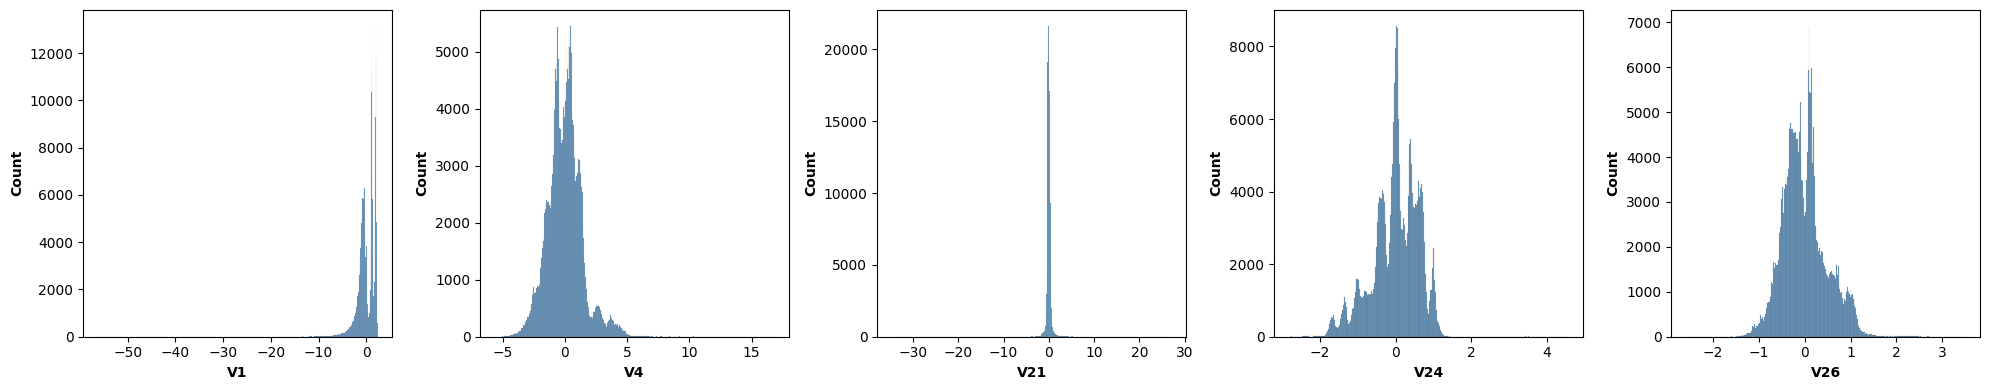

In [12]:
plots = ['V1', 'V4', 'V21', 'V24', 'V26']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, col in enumerate(plots):
    sns.histplot(data=df1, x=col, ax=axes[i], color='steelblue')
    axes[i].set_xlabel(col, fontweight='bold')
    axes[i].set_ylabel('Count', fontweight='bold')

plt.tight_layout()
plt.show()

Most **V1-V28** features show distributions close to normal centered near 0 as expected after PCA transformation, though many display skew with extremely thin tails, which suggests presence of extreme outliers. Five features have more notable distributional patterns:

**V1** has extreme left skew with two distinct spikes near 0 and a long tail extending to **-56**.

**V4** shows almost symmetrical distribution centered near 0 with several small spikes extending into the righ tail up to **+17**.

**V21** has a sharp central spike near 0 with thin tails on both sides. Several other features (V2, V3, V5, V7, V8, V20, V23, V27, V28) display similar patterns and were excluded to avoid repetition.

**V24** has unusual distribution with multiple peaks across the plot and the highest peak being close to 0.

**V26** shows a bimodal distribution with secondary peak to the left of the main distribution.

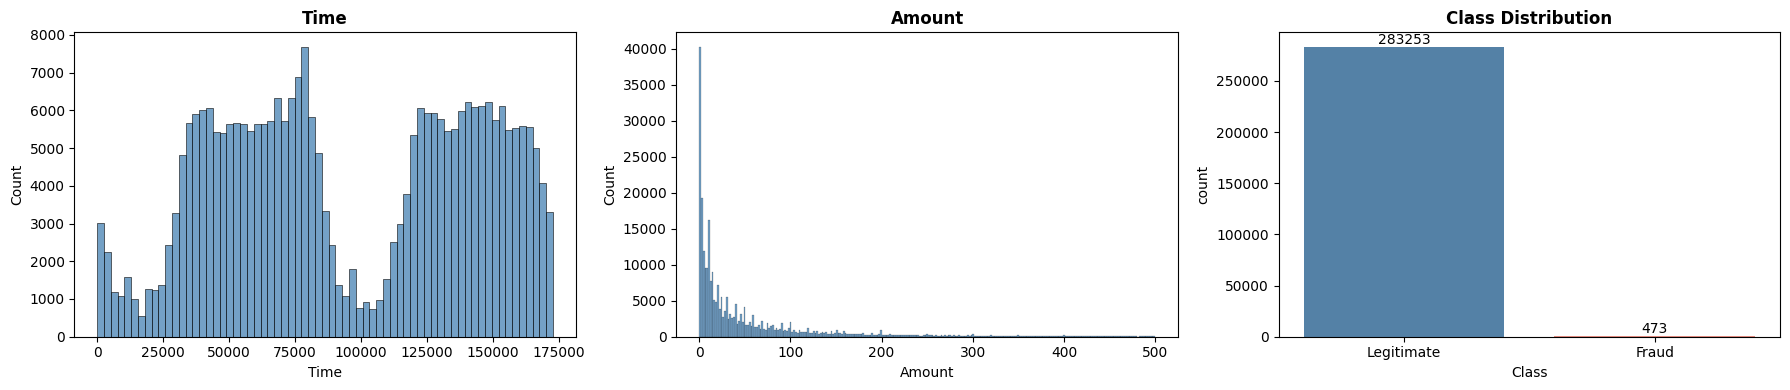

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(data=df1, x='Time', ax=axes[0], color='steelblue')
axes[0].set_title('Time', fontweight='bold')

sns.histplot(data=df1[df1['Amount']<500], x='Amount', ax=axes[1], color='steelblue')
axes[1].set_title('Amount', fontweight='bold')

legitimate = df1['Class'].value_counts()[0]
fraud = df1['Class'].value_counts()[1]

sns.countplot(data=df1, x='Class', ax=axes[2], hue='Class', legend=False, palette=['steelblue', 'salmon'])
axes[2].set_title('Class Distribution', fontweight='bold')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Legitimate', 'Fraud'])
axes[2].text(0, legitimate, f'{legitimate}', ha='center', va='bottom')
axes[2].text(1, fraud, f'{fraud}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Time** shows a bimodal distribution with two distinct peaks separated by a notable drop. It likely represents higher transaction volumes during daytime hours across the **48-hour** period covered by the dataset.

**Amount** is strongly right-skewed with the majority of transactions below **$100**, consistent with mean/median difference identified earlier. Transactions over **$500** were excluded from the plot to increase readability.

**Class Distribution** visually confirms severe class imbalance - **283,253** legitimate transactions versus only **473** fraud cases.

### Bivariate Analysis

#### Normalised Difference Table

Variables will be examined in relation to the target variable `Class` to identify potential predictors of fraud.

In [14]:
with pd.option_context('display.max_columns', None):
    display(df1.groupby('Class').mean())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,94835.058093,0.013439,-0.009829,0.012853,-0.010440,0.006769,0.001251,0.010447,-0.002448,0.002613,0.007663,-0.006004,0.009476,0.000762,0.011668,0.001166,0.007845,0.010963,0.005120,-0.001382,-0.000489,-0.00115,-0.000160,0.000360,0.000393,-0.000301,0.000065,0.001409,0.000418,88.413575
1,80450.513742,-4.498280,3.405965,-6.729599,4.472591,-2.957197,-1.432518,-5.175912,0.953255,-2.522124,-5.453274,3.716347,-6.103254,-0.094324,-6.835946,-0.072830,-4.000956,-6.463285,-2.157071,0.669143,0.405043,0.46655,0.086639,-0.096464,-0.106643,0.040615,0.050456,0.213774,0.078270,123.871860


The difference in means between fraudulent and legitimate transactions was calculated for each feature and normalised by standard deviation to conduct a fair comparison.

In [15]:
means = df1.groupby('Class').mean()
stds = df1.std()

normalised_diff = ((means.loc[1] - means.loc[0]) / stds).abs().sort_values(ascending=False)
print(normalised_diff)

V17       7.684501
V14       7.191247
V12       6.145458
V10       5.073300
V16       4.588323
V3        4.469101
V7        4.224576
V11       3.653948
V4        3.170048
V18       2.582098
V1        2.316046
V9        2.304659
V5        2.152467
V2        2.074323
V6        1.076459
V19       0.824370
V8        0.810567
V21       0.646076
V27       0.536622
V20       0.526675
Time      0.302953
V28       0.237337
V24       0.176735
V23       0.155240
Amount    0.141607
V22       0.119796
V26       0.104534
V13       0.095523
V15       0.080879
V25       0.078500
Class          NaN
dtype: float64


The analysis identified **14 strong predictors**: V17, V14, V12, V10, V16, V3, V7, V11, V4, V18, V1, V9, V5, V2. Other variables, including `Amount` and `Time`, show low normalised difference and are unlikely to be strong predictors.

#### Time vs Fraud Rate

Even though `Time` showed weak correlation, hourly analysis could still provide useful insights.

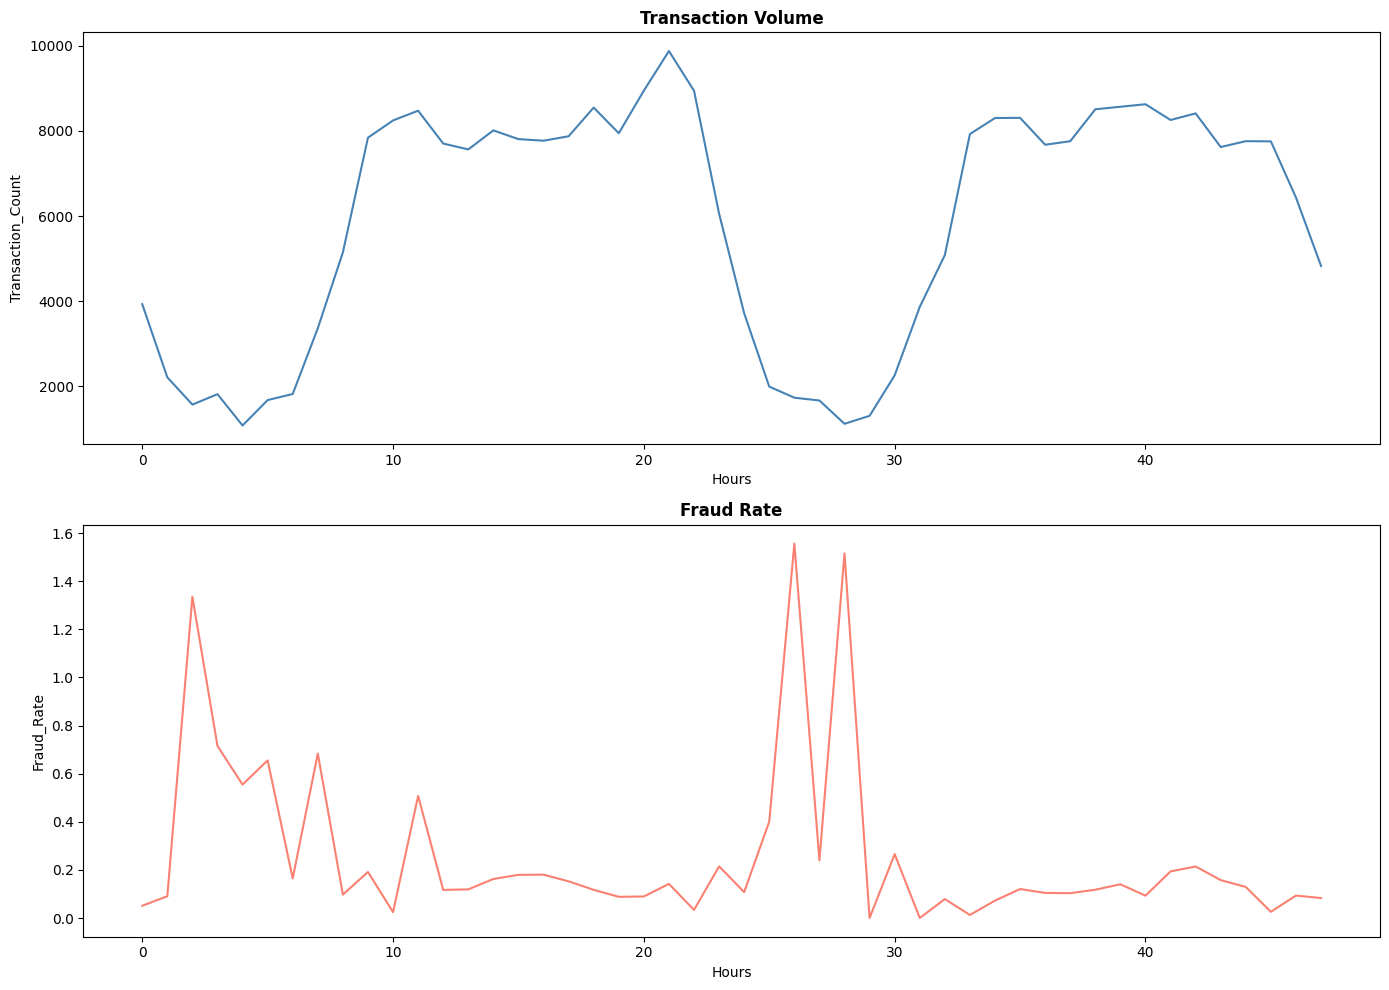

In [16]:
df2 = df1.copy()

df2['Hours'] = np.floor(df2['Time'] / 3600)

agg = df2.groupby('Hours').agg({
    'Class': ['mean', 'count', 'sum']
}).reset_index()

agg.columns = ['Hours', 'Fraud_Rate', 'Transaction_Count', 'Fraud_Count']

agg['Fraud_Rate'] = agg['Fraud_Rate'] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

sns.lineplot(data=agg, x='Hours', y='Transaction_Count', 
             color='steelblue', ax=axes[0])
axes[0].set_title('Transaction Volume', fontweight='bold')

sns.lineplot(data=agg, x='Hours', y='Fraud_Rate', 
             color='salmon', ax=axes[1])
axes[1].set_title('Fraud Rate', fontweight='bold')

plt.tight_layout()
plt.show()

As already mentioned earlier, transaction volume shows a bimodal distribution consistent with two business days. 

Fraud rate reveals elevated activity during **low volume periods** - especially during early hours (**2-5**) and around hours **26-29**, where fraud rate spikes to **1.57%** compared to average of **0.167%**. This suggests fraudsters may deliberately target quieter periods when suspicious activity is harder to detect.

#### Box plots

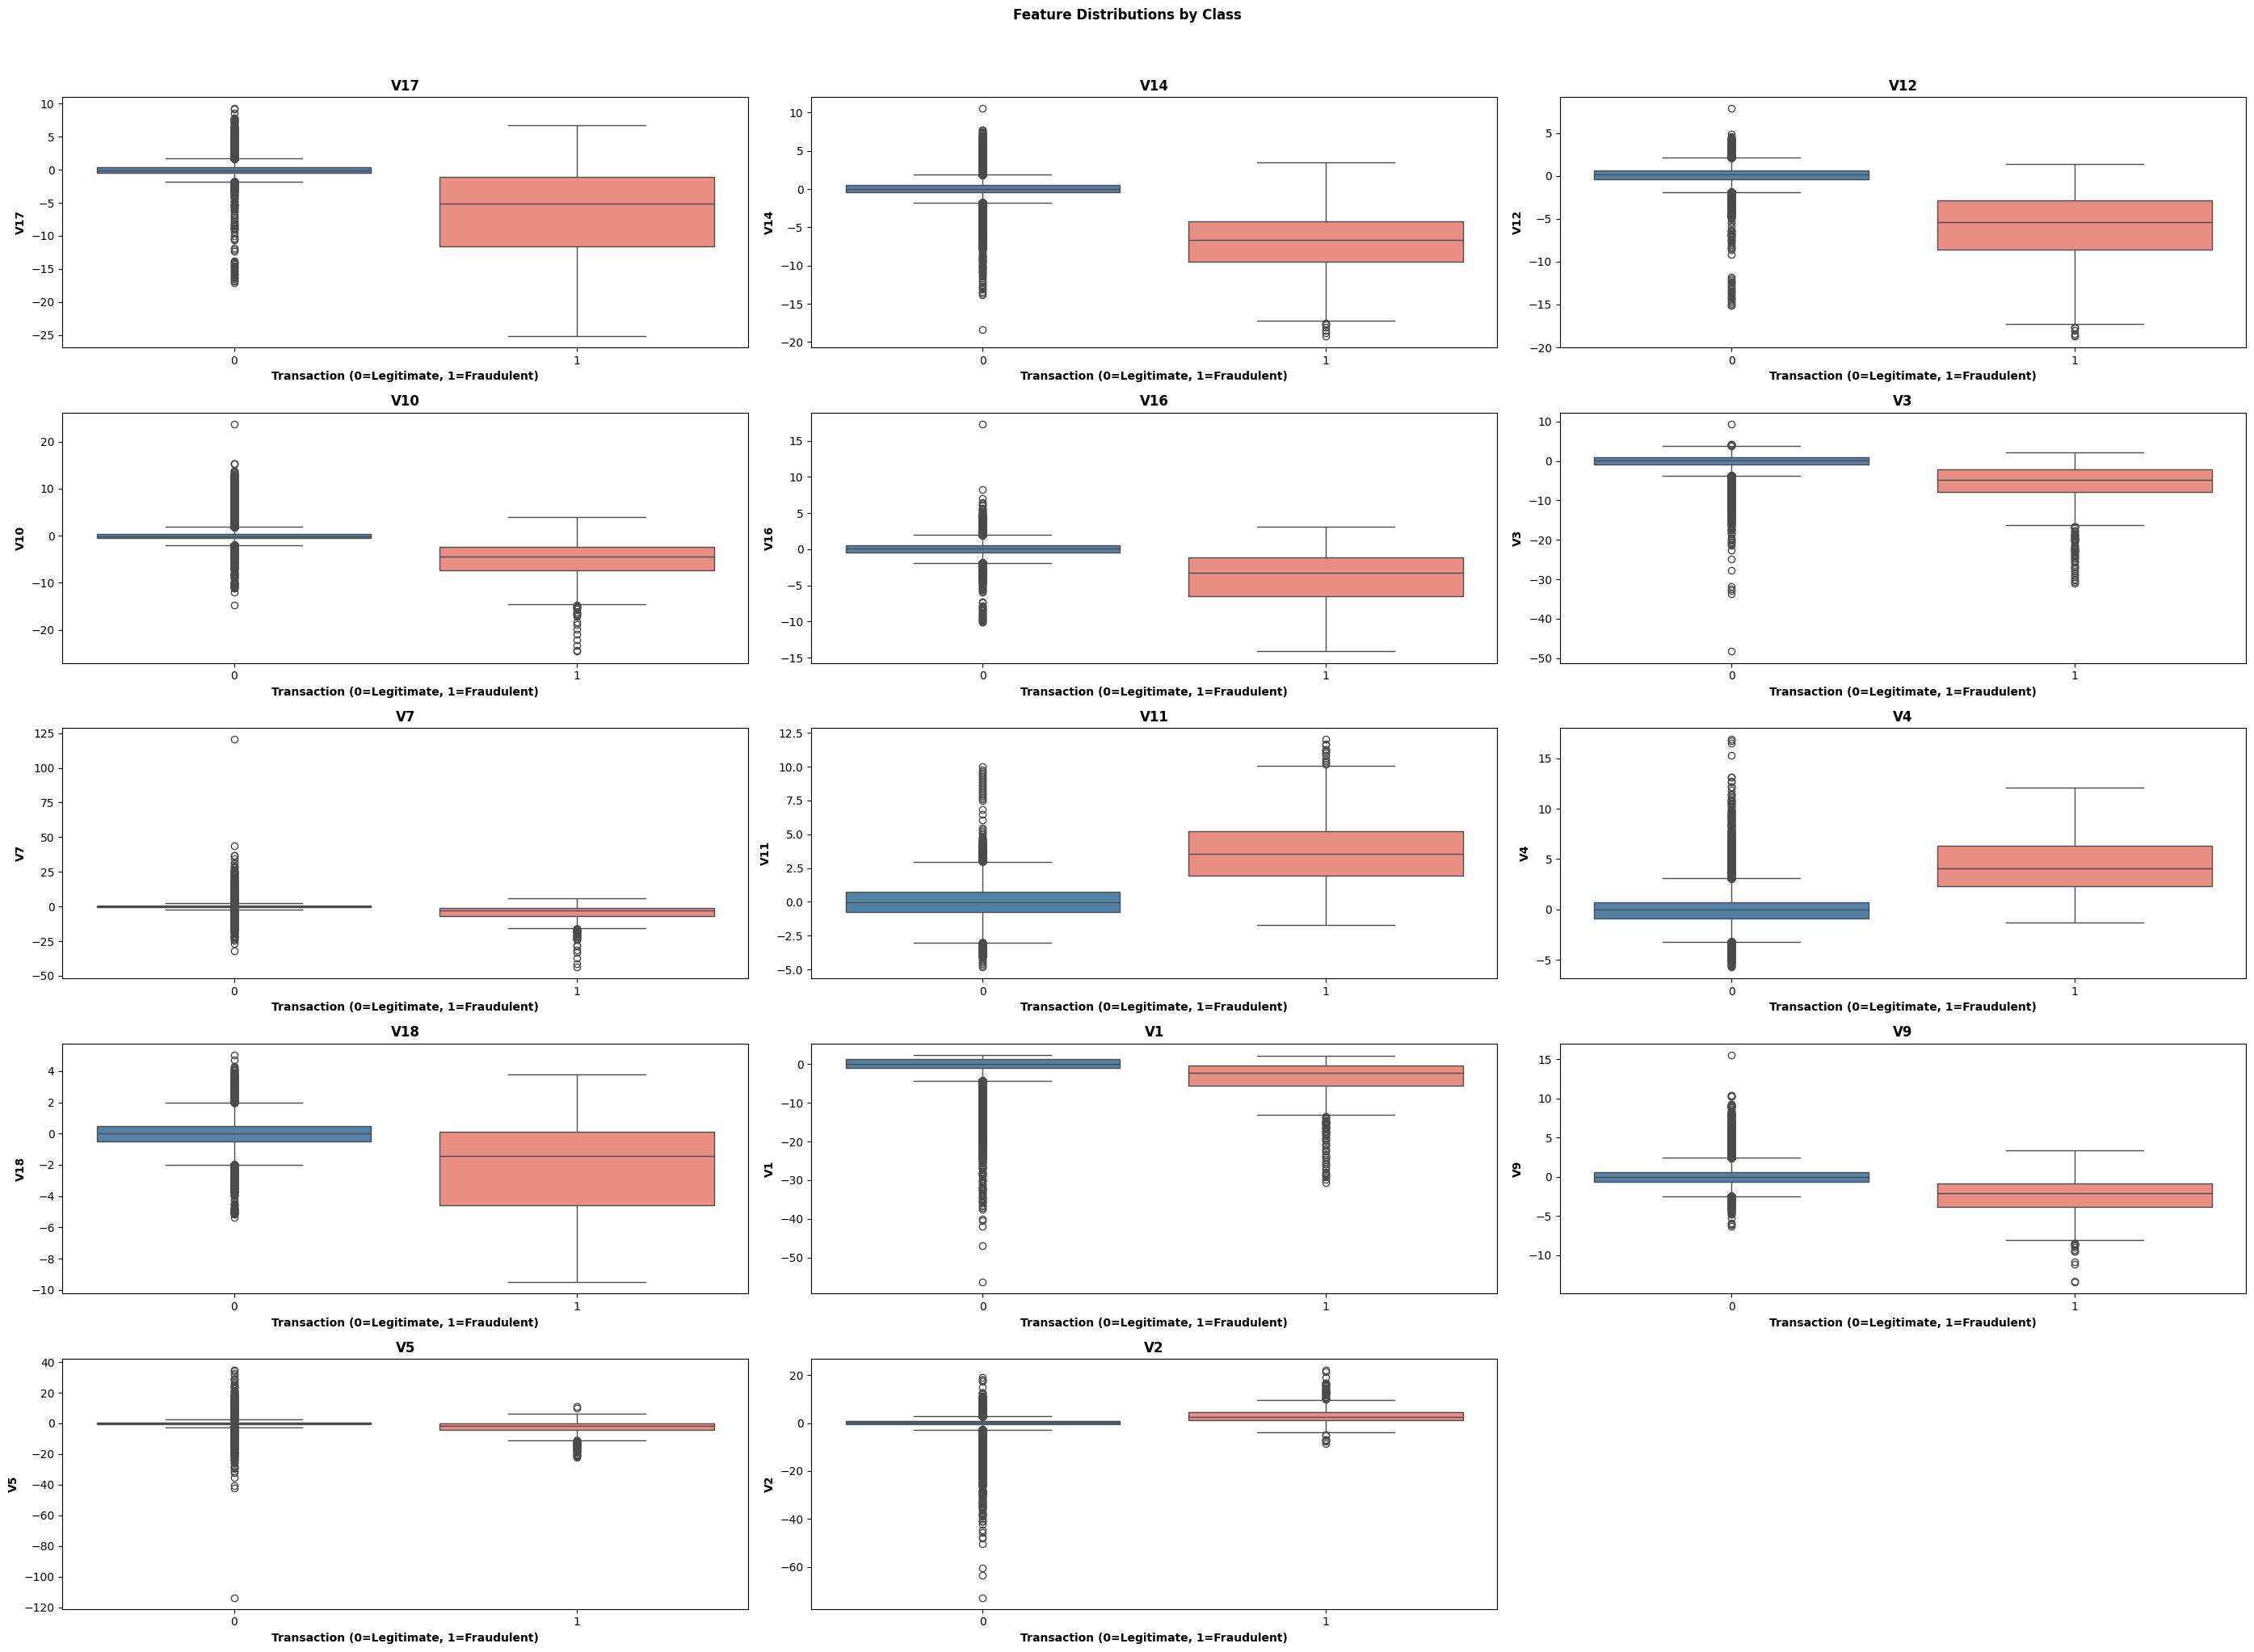

In [17]:
fig, axes = plt.subplots(5, 3, figsize=(28, 20))

strongest_predictors = ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 
                  'V11', 'V4', 'V18', 'V1', 'V9', 'V5', 'V2']

for i, col in enumerate(strongest_predictors):
    ax = axes[i//3, i%3]
    sns.boxplot(data=df1, x='Class', y=col, ax=ax,
                hue='Class', legend=False,
                palette={0: 'steelblue', 1: 'salmon'})
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Transaction (0=Legitimate, 1=Fraudulent)', fontweight='bold')
    ax.set_ylabel(col, fontweight='bold')

axes[4, 2].set_visible(False)

plt.suptitle('Feature Distributions by Class', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Box plots **confirm** difference between fraudulent and legitimate transactions across the top 14 features. Most features show fraudulent transactions clustering sgnificatly **below 0** (**V17, V14, V12, V10, V16, V7, V18, V9**), while others show fraud clustering **above 0** (**V11, V4, V2**). **V1** and **V3** show a different pattern - both classes display wide distributions with extreme outliers and fraudulent transactions having lower medians compared to legitimate ones. **V5** shows similar distributions for both classes with less clear separation.

#### Correlation Heatmap

A correlation heatmap will be used to check for realtionships between variables.

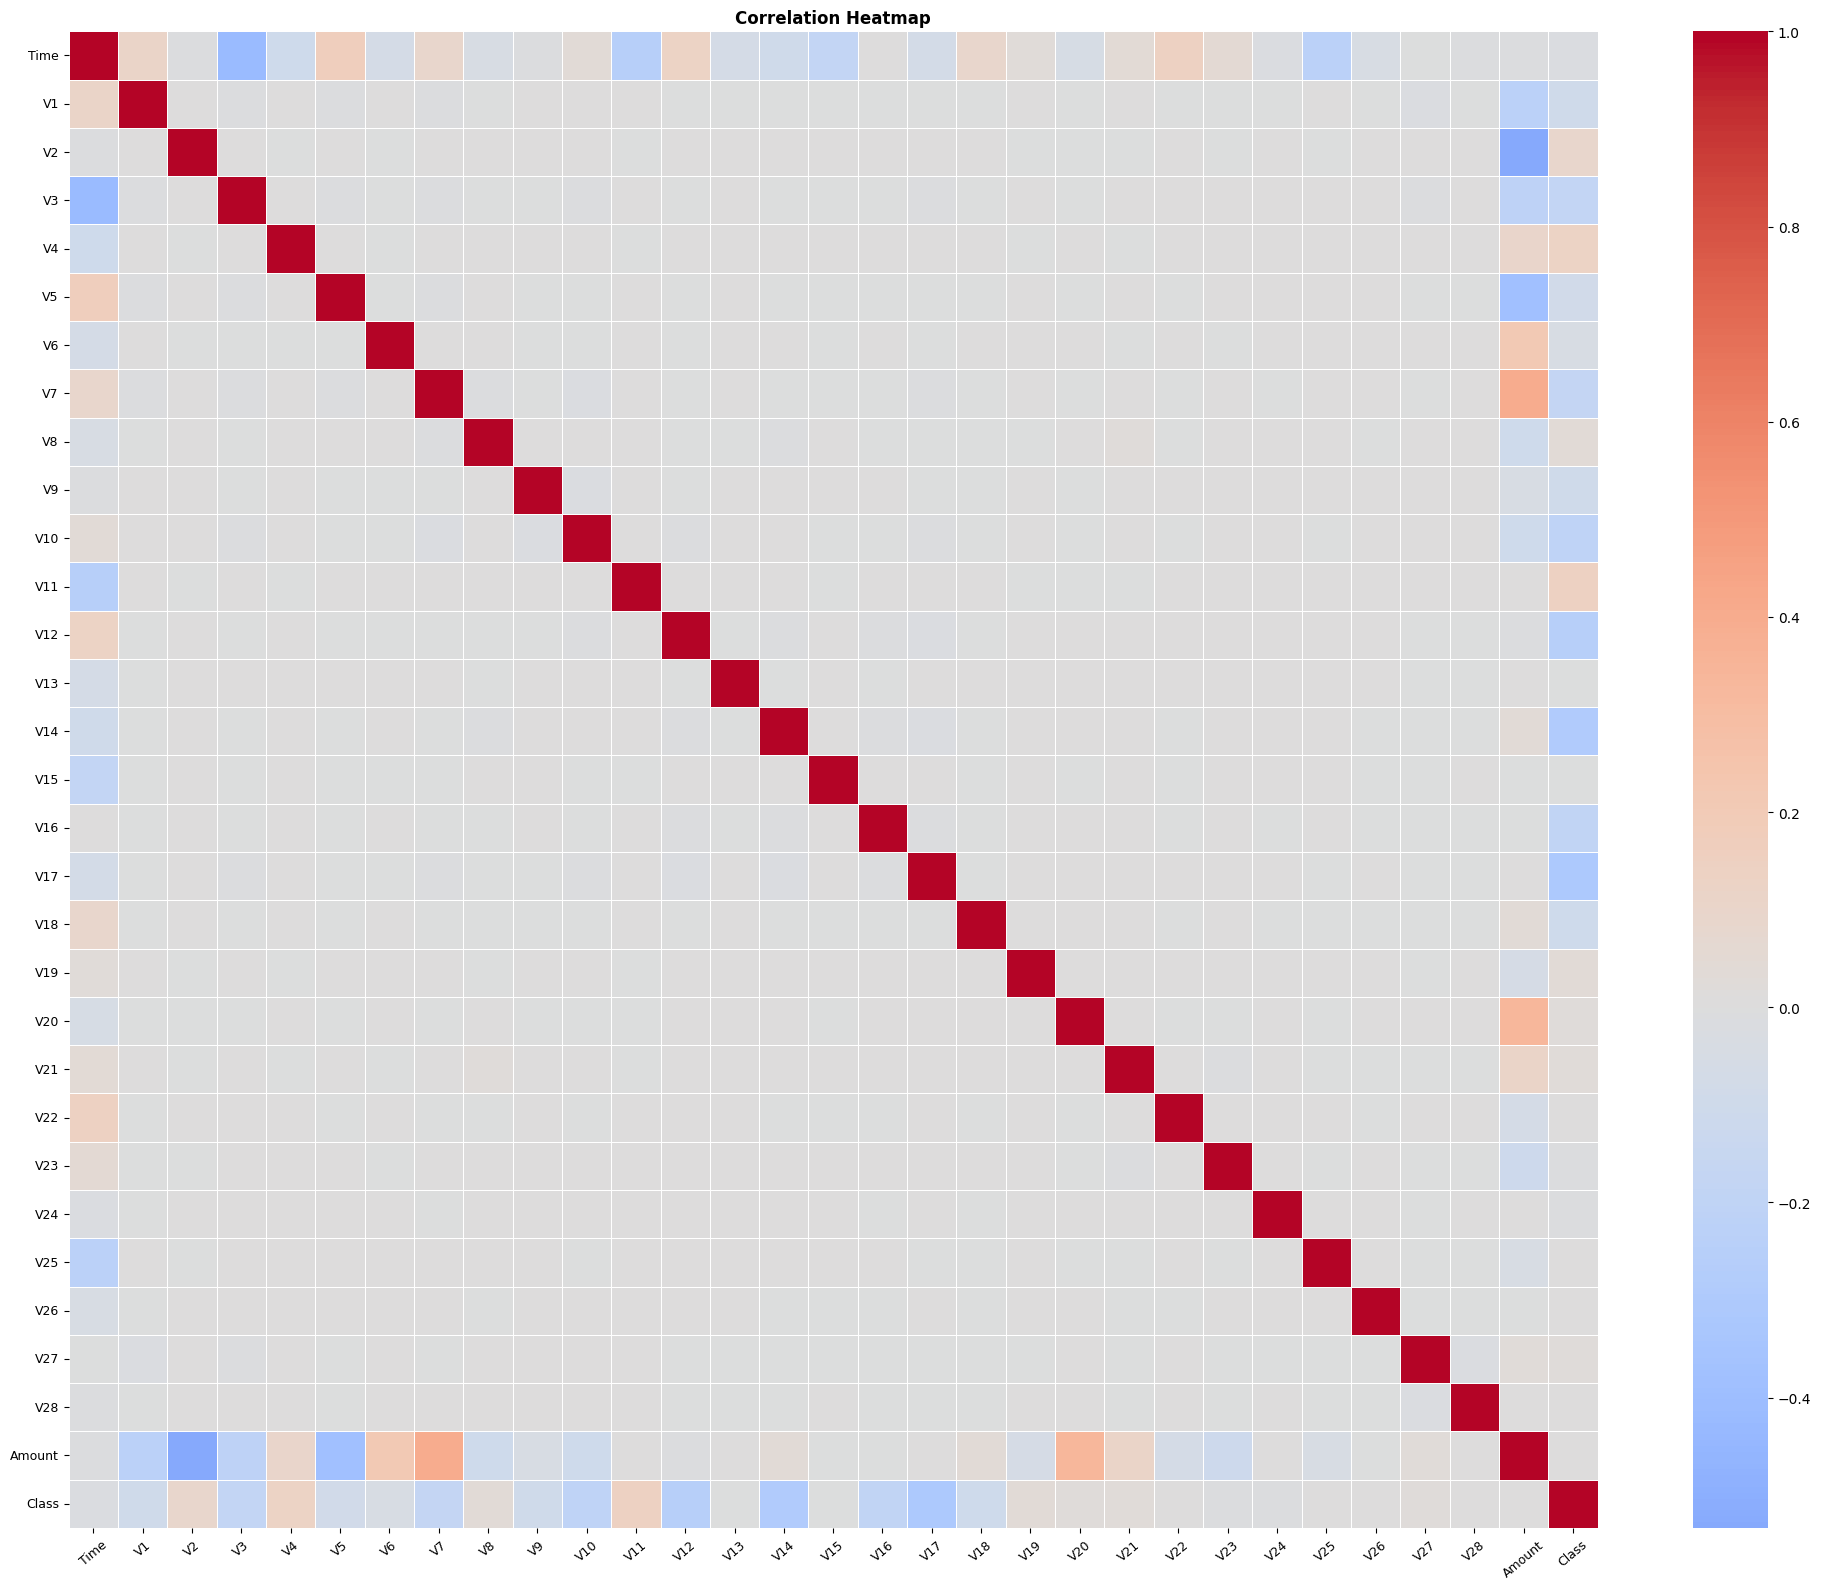

In [18]:
plt.figure(figsize=(20, 16))
sns.heatmap(data=df1.corr(), annot=False,
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap', fontweight='bold')
plt.xticks(rotation=40, fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

The correlation heatmap confirms that `V1-V28` features are uncorrelated with each other, which is a direct result of PCA transformation. `Class` row shows that **V17, V14, V12, V10** and **V3** have the strongest negative correlation with target variable, while **V11, V4** and **V2** show positive correlation. `Amount` and `Time` show no significant correlation with `Class`, which confirms earlier findings.

### EDA Summary

- **14 strong predictors** were identified: V17, V14, V12, V10, V16, V3, V7, V11, V4, V18, V1, V9, V5, V2.
- `Amount` and `Time` showed low normalised difference and are unlikely to be strong predictors. 
- Severe class imbalance was confirmed - **283,253** legitimate transactions versus only **473** fraud cases.
- Fraud rate showed elevated activity during **low volume periods** - especially during early hours(**2-5**) and around hours **26-29**, where fraud rate spikes to **1.57%** compared to average of **0.167%**.
- `V1-V28` features are uncorrelated with each other, which is a direct result of PCA transformation.
- Most features show fraudulent transactions clustering significantly **below 0** (**V17, V14, V12, V10, V16, V7, V18, V9**), while others show fraud clustering **above 0** (**V11, V4, V2**).

Due to the non-linear relationship between variables and severe class imbalance, three models will be created and compared: **Logistic Regression**, **Random Forest** and **XGBoost**. Class imbalance will be addressed using **SMOTE**.

## Feature Engineering

Before modelling, `Hour` feature will be created in order to create more convenient and practical thresholds. `Amount` will be logarithmized to get rid of skewed distribution to address the right skew in transaction amounts.

In [19]:
# Create a copy used for modeling
df_model = df1.copy()

# Hour feature created
df_model['Hour'] = np.floor(df_model['Time']/3600) % 24

# Amount feature logarithmized
df_model['Amount_log'] = np.log1p(df_model['Amount'])
df_model = df_model.drop(columns=['Amount'])

# Verify
df_model.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Class,Hour,Amount_log
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.0,5.014760
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,0.0,1.305626
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,0.0,5.939276
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.0,4.824306
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.0,4.262539


In [20]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 32 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Time        283726 non-null  float64
 1   V1          283726 non-null  float64
 2   V2          283726 non-null  float64
 3   V3          283726 non-null  float64
 4   V4          283726 non-null  float64
 5   V5          283726 non-null  float64
 6   V6          283726 non-null  float64
 7   V7          283726 non-null  float64
 8   V8          283726 non-null  float64
 9   V9          283726 non-null  float64
 10  V10         283726 non-null  float64
 11  V11         283726 non-null  float64
 12  V12         283726 non-null  float64
 13  V13         283726 non-null  float64
 14  V14         283726 non-null  float64
 15  V15         283726 non-null  float64
 16  V16         283726 non-null  float64
 17  V17         283726 non-null  float64
 18  V18         283726 non-null  float64
 19  V19         283726

The resulting dataset contains **283,726 observations** and **32 features**.

## Modelling

### Model choice

For further analysis **Logistic Regression**, **Random Forest** and **XGBoost** will be used.

These three models will be compared based on their effectiveness at fraud identification. The main metric, which will be used to refit the models, is **recall**, as in case of fraud identification false negative is more costly in terms of financial and reputational damage.


### Dataset split

The dataset will be split into training and test sets before modelling. The model will be trained on the training set and evaluated on the test set to see how well it performs on new data it hasn't seen before.

In [21]:
X = df_model.drop(columns=['Class'])
y = df_model['Class']

X_train_original, X_test, y_train_original, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Training set:', X_train_original.shape)
print('Test set:', X_test.shape)

Training set: (226980, 31)
Test set: (56746, 31)


The dataset was split into training (80%) and test (20%) sets, resulting in 226,980 training and 56,746 test samples. `stratify=y` was used to maintain the original class balance across both sets.

SMOTE will be used in order to balance fraudulent and legitimate transaction in training set. This way model's bias towards legitimate transactions will be reduced.

In [22]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_original, y_train_original)

Scoring metrics used across models are established below.

In [23]:
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

### Logistic Regression model

The dataset will be scaled in order to standardize features, which is required for Logistic Regression to perform correctly..

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

The baseline model will be created using default hyperparameters.

In [25]:
lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_scaled, y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

**GridSearchCV** will be used to find best C-feature for Logistic Regression model.

In [26]:
# Setting parameters
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'max_iter': [1000]
    }

# Hyperparameter tuning
lr_tuned = GridSearchCV(lr_model, lr_params, scoring=scoring, cv=4, refit='recall', n_jobs=-1)

# Fitting train data
lr_tuned.fit(X_train_scaled, y_train_res)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'max_iter': [1000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is al

In [27]:
lr_tuned.best_params_

{'C': 100, 'max_iter': 1000}

In [28]:
print(f'Best recall: {lr_tuned.best_score_:.4f}')

Best recall: 0.9725


The hyperparameters were tuned using GridSearchCV optimising for **recall** evaluated across **4 cross-validation folds**. The best `C-parameter = 100`. The best cross-validation `recall` was **0.9725**.

The model will be used to generate predictions on the test set. These predictions will then be evaluated using key metrics - accuracy, precision, recall and F1 score.

In [29]:
# Predictions
y_pred = lr_tuned.predict(X_test_scaled)
y_pred_proba = lr_tuned.predict_proba(X_test_scaled)[:, 1]

# Classification report
print(classification_report(y_test, y_pred))

# ROC-AUC
auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC: {auc:.4f}')

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.13      0.85      0.23        95

    accuracy                           0.99     56746
   macro avg       0.57      0.92      0.61     56746
weighted avg       1.00      0.99      0.99     56746

ROC-AUC: 0.9633


The logistic regression model showed good results on **recall** (**0.85**), which means that the model was able to identify 85% of fraudulent transactions. However, **precision** and, subsequently, **f1** had lows scores (**0.13** and **0.23**), which means that the model is biased towards fraudulent transactions and can return a high number of false postive results. ROC-AUC score has showed a good result as well (**0.9633**).

The model's prediction will be visualised using a confusion matrix.

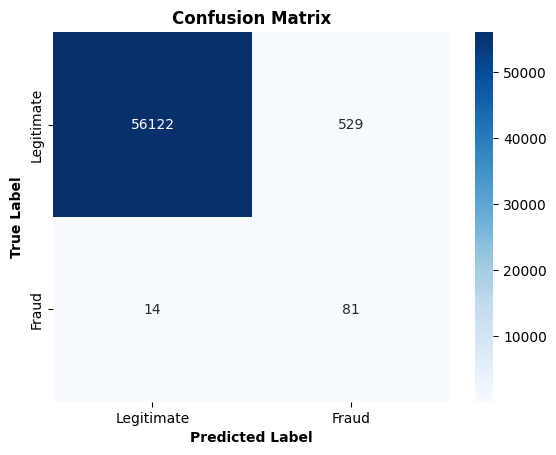

In [30]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(data=cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.show()

The confusion matrix shows the model correctly identified **81 out of 95** actual fraud, missing **14** - approximately **14.7%** of fraudulent transactions. **529** transactions were flagged incorrectly, which corresponds with low precision.

The model will be evaluated on the training set to check for overfitting by comparing training and test performance.

In [31]:
X_train_original_scaled = scaler.transform(X_train_original)
y_pred_train = lr_tuned.predict(X_train_original_scaled)
print(classification_report(y_train_original, y_pred_train))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    226602
           1       0.14      0.89      0.24       378

    accuracy                           0.99    226980
   macro avg       0.57      0.94      0.62    226980
weighted avg       1.00      0.99      0.99    226980



Results of test on train data are almost identical to the ones ran on test data, which means that there is no overfitting problem.

### Random Forest Classifier Model

#### First model

Random Forest Classifier model will be created using default hyperparameters.

In [32]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42
)

rf_model.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

**GridSearchCV** will be used to find the optimal combination of hyperparameters.

In [33]:
# Setting parameters
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
    }

# Hyperparameter tuning
rf_tuned = GridSearchCV(rf_model, rf_params, scoring=scoring, cv=4, refit='recall', n_jobs=-1)

# Fitting train data
rf_tuned.fit(X_train_res, y_train_res)  

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramet

In [34]:
rf_tuned.best_params_

{'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 100}

In [35]:
print(f'Best recall: {rf_tuned.best_score_:.4f}')

Best recall: 1.0000


The hyperparameters were tuned using GridSearchCV optimising for **recall** by testing **27 different combinations**, each evaluated across **4 cross-validation folds**. The best parameters found were `n_estimators=100`, `max_depth=20` and `min_samples_leaf=2`. The best cross-validation `recall` was **1.00**.

In [36]:
# Predictions
y_pred_tuned = rf_tuned.best_estimator_.predict(X_test)
y_pred_proba_tuned = rf_tuned.best_estimator_.predict_proba(X_test)

# Classification report
print(classification_report(y_test, y_pred_tuned))

# ROC-AUC
auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned[:, 1])
print(f'ROC-AUC: {auc_tuned:.4f}')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.78      0.83        95

    accuracy                           1.00     56746
   macro avg       0.95      0.89      0.92     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9540


The Random Forest Classifier model showed good results on **recall** (**0.78**), which means that the model was able to identify 78% of fraudulent transactions. **Precision** and **f1** scores were also high (**0.89** and **0.83**), which means that the model returns a small amount of false positives. ROC-AUC score has showed a good result as well (**0.954**).

In [37]:
rf_y_pred_train = rf_tuned.predict(X_train_original)
print(classification_report(y_train_original, rf_y_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    226602
           1       0.92      1.00      0.96       378

    accuracy                           1.00    226980
   macro avg       0.96      1.00      0.98    226980
weighted avg       1.00      1.00      1.00    226980



Results of test on training data suggest **overfitting**, so the second round of tuning will be performed.

#### Second model

In [38]:
# Setting parameters
rf_params2 = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [2, 5, 10]
    }

# Hyperparameter tuning
rf_tuned_v2 = GridSearchCV(rf_model, rf_params2, scoring=scoring, cv=4, refit='recall', n_jobs=-1)

# Fitting train data
rf_tuned_v2.fit(X_train_res, y_train_res)  

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [2, 5, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [39]:
rf_tuned_v2.best_params_

{'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}

In [40]:
print(f'Best recall: {rf_tuned_v2.best_score_:.4f}')

Best recall: 0.9876


The hyperparameters were tuned using GridSearchCV by testing **24 different combinations**. The best parameters found were `n_estimators=200`, `max_depth=10` and `min_samples_leaf=5`. The best cross-validation `recall` was **0.9876**, which is lower compared to the first version.

In [41]:
# Predictions
y_pred_tuned_v2 = rf_tuned_v2.best_estimator_.predict(X_test)
y_pred_proba_tuned_v2 = rf_tuned_v2.best_estimator_.predict_proba(X_test)

# Classification report
print(classification_report(y_test, y_pred_tuned_v2))

# ROC-AUC
auc_tuned_v2 = roc_auc_score(y_test, y_pred_proba_tuned_v2[:, 1])
print(f'ROC-AUC: {auc_tuned_v2:.4f}')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.60      0.82      0.69        95

    accuracy                           1.00     56746
   macro avg       0.80      0.91      0.85     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9768


In [42]:
y_pred_train_tuned_v2 = rf_tuned_v2.best_estimator_.predict(X_train_original)
print(classification_report(y_train_original, y_pred_train_tuned_v2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    226602
           1       0.64      0.97      0.77       378

    accuracy                           1.00    226980
   macro avg       0.82      0.98      0.88    226980
weighted avg       1.00      1.00      1.00    226980



The second version of Random Forest Classifier model showed better results on **recall** (**0.82** vs **0.78**), which means that the model became better at identifying actual fraud. **Precision** and **f1** scores dropped significantly (**0.60 and 0.69** vs **0.89** and **0.83**), meaning the newer model returns more false positives. ROC-AUC score increased (**0.9768**).

On the other hand, the results of test on training data show that the problem of overfitting has been solved.

Since the second version of the model showed low precision, third round of tuning will be conducted to improve it.

#### Third model

Cap of `max_depth` will be increased to 15 to to find a better balance between overfitting and performance.

In [43]:
# Setting parameters
rf_params3 = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'min_samples_leaf': [2, 3, 5]
    }

# Hyperparameter tuning
rf_tuned_v3 = GridSearchCV(rf_model, rf_params3, scoring=scoring, cv=4, refit='recall', n_jobs=-1)

# Fitting train data
rf_tuned_v3.fit(X_train_res, y_train_res)  

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15], 'min_samples_leaf': [2, 3, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [44]:
rf_tuned_v3.best_params_

{'max_depth': 15, 'min_samples_leaf': 3, 'n_estimators': 100}

In [45]:
print(f'Best recall: {rf_tuned_v3.best_score_:.4f}')

Best recall: 0.9998


The best parameters found by GridSearchCV were `n_estimators=100`, `max_depth=15` and `min_samples_leaf=3`. The best cross-validation `recall` was **0.9998**.

In [46]:
# Predictions
y_pred_tuned_v3 = rf_tuned_v3.best_estimator_.predict(X_test)
y_pred_proba_tuned_v3 = rf_tuned_v3.best_estimator_.predict_proba(X_test)

# Classification report
print(classification_report(y_test, y_pred_tuned_v3))

# ROC-AUC
auc_tuned_v3 = roc_auc_score(y_test, y_pred_proba_tuned_v3[:, 1])
print(f'ROC-AUC: {auc_tuned_v3:.4f}')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.82      0.80      0.81        95

    accuracy                           1.00     56746
   macro avg       0.91      0.90      0.90     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9684


The third tuning round significantly improved precision (**0.82** vs **0.60**), while recall stayed high (**0.80** vs **0.82**). ROC-AUC also remained high at **0.9684**.

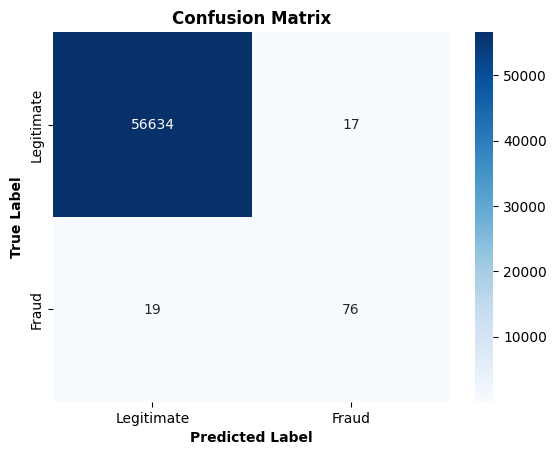

In [47]:
cm = confusion_matrix(y_test, y_pred_tuned_v3)
sns.heatmap(data=cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.show()

The confusion matrix shows the model correctly identified **76 out of 95** actual fraud, missing **19** - approximately **20%** of fraudulent transactions. **17** transactions were flagged incorrectly, which is a huge improvement compared to Logistic Regression and corresponds with high precision.

In [48]:
y_pred_train_tuned_v3 = rf_tuned_v3.best_estimator_.predict(X_train_original)
print(classification_report(y_train_original, y_pred_train_tuned_v3))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    226602
           1       0.86      1.00      0.92       378

    accuracy                           1.00    226980
   macro avg       0.93      1.00      0.96    226980
weighted avg       1.00      1.00      1.00    226980



The third tuning round produced the most balanced model. Train precision (**0.86**) and test precision (**0.82**) are very close, suggesting the overfitting problem has been addressed. Train recall remains at 1.00, which is expected given the model has only seen 378 reak fraud cases during training. 

On the test set the model achieved precision of 0.82, recall of 0.80, F1 of 0.81 and ROC-AUC of 0.9684, making it the strongest Random Forest version and the one selected for final comparison.

### XGBoost

XGBoost model will be created using default hyperparameters.

In [49]:
xgb_model = XGBClassifier(random_state=42, n_jobs=-1)

**GridSearchCV** will be used to find the optimal combination of hyperparameters.

In [50]:
# Setting parameters
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
    }

# Hyperparameter tuning
xgb_tuned = GridSearchCV(xgb_model, xgb_params, scoring=scoring, cv=4, refit='recall', n_jobs=-1)

# Fitting train data
xgb_tuned.fit(X_train_res, y_train_res)  

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time fo

In [51]:
xgb_tuned.best_params_

{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

In [52]:
print(f'Best recall: {xgb_tuned.best_score_:.4f}')

Best recall: 1.0000


The hyperparameters were tuned using GridSearchCV optimising for **recall** by testing **36 different combinations**, each evaluated across **4 cross-validation folds**. The best parameters found were `n_estimators=200`, `max_depth=7` and `learning_rate=0.1`, `subsample=0.8`. The best cross-validation `recall` was **1.00**.

In [53]:
# Predictions
xgb_y_pred_tuned = xgb_tuned.best_estimator_.predict(X_test)
xgb_y_pred_proba_tuned = xgb_tuned.best_estimator_.predict_proba(X_test)

# Classification report
print(classification_report(y_test, xgb_y_pred_tuned))

# ROC-AUC
xgb_auc_tuned = roc_auc_score(y_test, xgb_y_pred_proba_tuned[:, 1])
print(f'ROC-AUC: {xgb_auc_tuned:.4f}')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.88      0.80      0.84        95

    accuracy                           1.00     56746
   macro avg       0.94      0.90      0.92     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9675


The XGBoost model showed good results on **recall** (**0.80**). **Precision** and **f1** scores were also high (**0.88** and **0.84**). ROC-AUC score has showed a good result as well (**0.968**), which is the highest result so far.

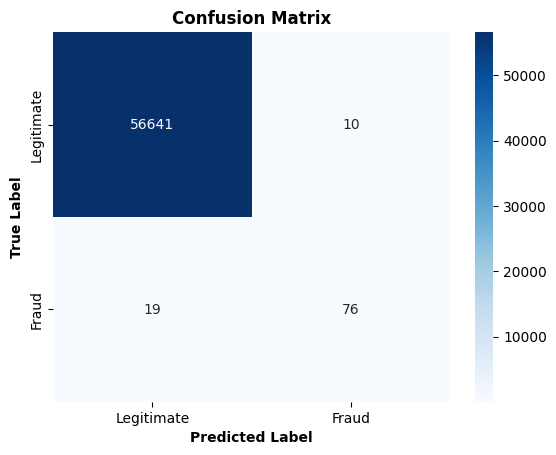

In [54]:
cm = confusion_matrix(y_test, xgb_y_pred_tuned)
sns.heatmap(data=cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.show()

The confusion matrix shows the model correctly identified **76 out of 95** actual fraud, missing **20%** of fraudulent transactions. Only **10** transactions were flagged incorrectly, which corresponds with high precision.

In [55]:
xgb_y_pred_train_tuned = xgb_tuned.best_estimator_.predict(X_train_original)
print(classification_report(y_train_original, xgb_y_pred_train_tuned))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    226602
           1       1.00      1.00      1.00       378

    accuracy                           1.00    226980
   macro avg       1.00      1.00      1.00    226980
weighted avg       1.00      1.00      1.00    226980



XGBoost achieves perfect scores across all metrics on the training set. Unlike the Random Forest models, XGBoost consistently returns 1.00 on train evaluation, which suggests the model has memorised the 378 fraud cases in the original training data. 

However, strong test results (precision 0.88, recall 0.80, F1 0.84, ROC-AUC 0.9675) indicates that the model still performs well on unseen data.

### Model comparison

Three final models will be compared across 4 main metrics (precision, recall, f1 and ROC-AUC) in order to choose the best one for fraud detection.

| Model | Precision | Recall | F1 | ROC-AUC | Train-Test Average Gap |
|--------|:------:|:-------------:|:-------------:|:-----------:|:-----------:|
| Logistic Regression | 0.13 | 0.85 | 0.23 | 0.9634 | 0.02 |
| Random Forest | 0.82 | 0.80 | 0.81 | 0.9684 | 0.12 |
| XGBoost | 0.88 | 0.80 | 0.84 | 0.9675 |  0.16 |

The choice comes down to two best models: Random Forest and XGBoost. Even though Logistic Regression has the highest recall, its precision is extremely low and can potentially lead to many legitimate transactions being flagged and reported as fraudulent, which worsens customers' experience with the bank.

XGBoost performs better on precision and F1 and has the same recall as Random Forest. On the other hand, Random Forest has slightly higher ROC-AUC and has lower train-test average gap, which means that it is more generalised and identified patterns more effectively.

Both models can be used for fraud detection. In this case, XGBoost will be chosen. Its higher precision (0.88) and F1 (0.84) make it the most balanced performer, minimising false positives while maintaining strong recall. Although the model shows signs of overfitting on training data, its strong test performance suggests it performs well on unseen transactions.

### Feature importance

Feature importance scores from the **XGBoost** model will be used to determine which variables contribute most to fraud detection.

In [56]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_tuned.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance)

       feature  importance
14         V14    0.718997
12         V12    0.039346
4           V4    0.039297
17         V17    0.029120
3           V3    0.010634
11         V11    0.010445
9           V9    0.010430
10         V10    0.010365
8           V8    0.009788
1           V1    0.009073
19         V19    0.007920
29        Hour    0.007913
13         V13    0.007674
18         V18    0.007278
25         V25    0.007268
15         V15    0.006902
0         Time    0.005971
22         V22    0.005680
7           V7    0.005614
5           V5    0.005442
30  Amount_log    0.005152
2           V2    0.005131
21         V21    0.004866
16         V16    0.004840
26         V26    0.004786
20         V20    0.004560
23         V23    0.003765
6           V6    0.003697
28         V28    0.003545
24         V24    0.002934
27         V27    0.001567


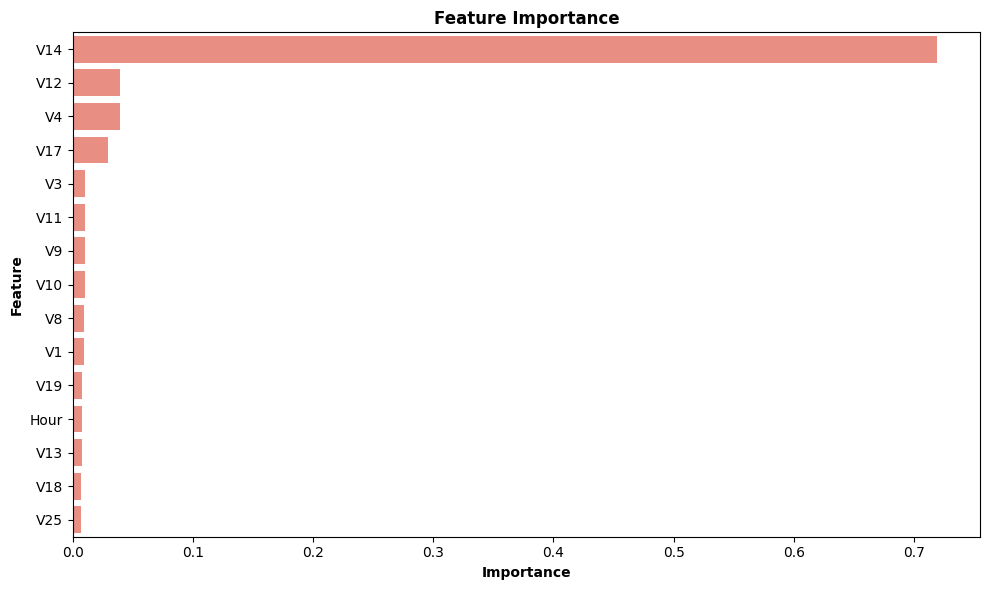

In [57]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature', color='salmon')
plt.title('Feature Importance', fontweight='bold')
plt.xlabel('Importance', fontweight='bold')
plt.ylabel('Feature', fontweight='bold')
plt.tight_layout()
plt.show()

Feature importance analysis identified `V14` to be the dominant predictor of fraud by a significant margin (**0.72**), compared to V17 which ranked highest in EDA. `V12` (**0.04**), `V4` (**0.04**) and `V17` (**0.03**) form a distant second tier. Notably, `Hour` (**0.008**) and `Time` (**0.006**) appear to be weak predictors, which means that fraud timing pattern identified during EDA didn't translate into strong predicitive signal. `Amount_log` has also scored low, which is consistent with EDA. 

## Results & Recommendations

Fraudulent transactions result in financial losses for both banks and their customers. This project aimed to build a model, which would automatically detect fraudulent transactions. 

Three models were chosen as potential tools to solve this problem: Logistic Regression, Random Forest and XGBoost. 

Before creating these models some manipulations were done with the data. First, two features were engineered: `Amount_log` and `Hour`. `Amount_log` was created to address the right skew in transaction amounts. `Hour` was created from `Time` to test the hypothesis that fraudulent transactions take place during certain periods of time. After that **SMOTE** has been used to counter class imbalance.

Three models showed different performance on the test data. 

Logistic Regression had the highest recall (0.85), but its precision was extremely low (0.13), which could potentially lead to many legitimate transactions being flagged and reported as fraudulent, worsening customers' experience with the bank.

Random Forest and XGBoost performed well across all metrics with final choice depending on the priority. XGBoost had higher precision (0.88 vs 0.82) and F1 (0.84 vs 0.81), while Random Forest scored higher on ROC-AUC (0.9684 vs 0.9675) and had lower train-test average gap (0.12 vs 0.16). The recall was the same for both models. In the end, XGBoost has been chosen, as its higher precision and F1 made it the most balanced performer, minimising false positives while maintaining strong recall. Although the model showed signs of overfitting, its strong test performance suggests it performs well on unseen transactions.

Recommendations:
- Final model performed well on the test data, classifying 86 out of 56746 transactions as fraudulent. This volume makes it possible for employees to manually check these transactions in a short period of time.
- Threshold for fraud detection can be adjusted depending on the bank's priorities. Lowering the classification threshold will increase recall at the cost of higher false positives.
- Given that fraud evolves over time, the model should be retrained regularly on new transaction data to stay effective.
- `V14` feature, the primary predictor, should be investigated more closely. This was impossible to do after PCA, but the bank should be able to conduct deeper analysis.
- Hours with lower transaction volume should be monitored more extensively, as the amount of fraud increases during hours with lower overall activity.

The interpretability of the final results is limited because of data transformation using PCA. Future work could include real-time deployment and adjustments depending on the model performance.